In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('/content/track_in_competition.csv')

In [ ]:
df.head()

,track_id,in_apple_playlists,in_apple_charts,in_deezer_playlists,in_deezer_charts,in_shazam_charts
0,4082370,43,263,45,10,826
1,6247887,48,126,58,14,382
2,6974739,94,207,91,14,949
3,2362023,116,207,125,12,548
4,4386478,84,133,87,15,425


In [ ]:
df = pd.read_csv('track_in_spotify.csv')

In [ ]:
df.head()

,track_id,track_name,artist_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams
0,4082370,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703
1,6247887,LALA,Myke Towers,1,2023,3,23,1474,48,133716286
2,6974739,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974
3,2362023,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817
4,4386478,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322


In [ ]:
df = pd.read_csv('track_technical_info.csv')

In [ ]:
df.head()

,track_id,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,4082370,125,B,Major,80,89,83,31,0,8,4
1,6247887,92,C#,Major,71,61,74,7,0,10,4
2,6974739,138,F,Major,51,32,53,17,0,31,6
3,2362023,170,A,Major,55,58,72,11,0,11,15
4,4386478,144,A,Minor,65,23,80,14,63,11,6


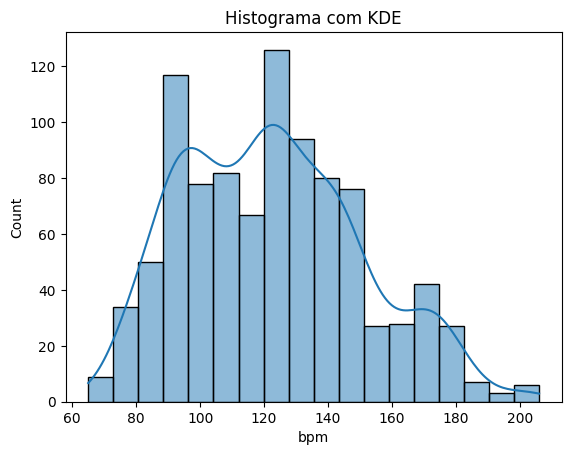

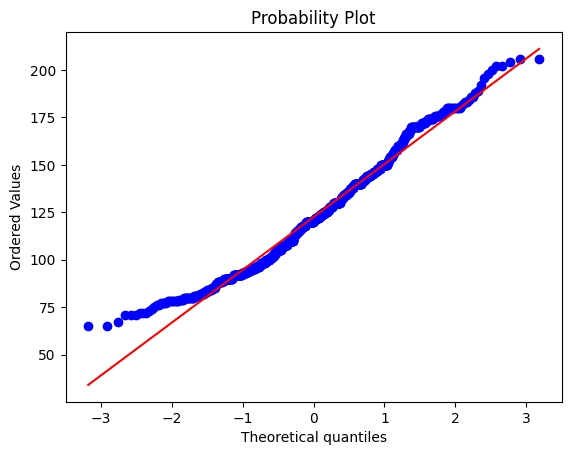

Shapiro-Wilk: ShapiroResult(statistic=np.float64(0.9775399719022942), pvalue=np.float64(5.849094903743323e-11))
D’Agostino and Pearson: NormaltestResult(statistic=np.float64(35.10886499105632), pvalue=np.float64(2.3779725346286604e-08))


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import shapiro, normaltest, kstest

# Exemplo: suponha que df['bpm'] é a sua variável
data = df['bpm'].dropna()

# Histograma e gráfico Q-Q
sns.histplot(data, kde=True)
plt.title("Histograma com KDE")
plt.show()

import scipy.stats as stats
import pylab

stats.probplot(data, dist="norm", plot=pylab)
pylab.show()

# Testes de normalidade
shapiro_test = shapiro(data)
dagostino_test = normaltest(data)

print("Shapiro-Wilk:", shapiro_test)
print("D’Agostino and Pearson:", dagostino_test)


In [ ]:
import pandas as pd

# Substitua os nomes abaixo se seus arquivos tiverem nomes diferentes
track_technical_info = pd.read_csv('track_technical_info.csv')
track_in_spotify = pd.read_csv('track_in_spotify.csv')
track_in_competition = pd.read_csv('track_in_competition.csv')

# TESTE DE SIGNIFICÂNCIA


# Hipótese 1

In [ ]:
from scipy.stats import spearmanr

# Juntando os dados
df = track_technical_info.merge(track_in_spotify, on='track_id')

# Correlação Spearman
corr, p = spearmanr(df['bpm'], df['streams'])
print("Correlação entre BPM e Streams (Spearman):", corr, "p-valor:", p)


Correlação entre BPM e Streams (Spearman): -0.010248769009473531 p-valor: 0.7520179059448279


# Hipótese 2

In [ ]:
# Juntando os dados
df = track_in_spotify.merge(track_in_competition, on='track_id')

# Correlação entre rankings
corr, p = spearmanr(df['in_spotify_charts'], df['in_deezer_charts'])
print("Correlação entre Spotify e Deezer charts (Spearman):", corr, "p-valor:", p)


Correlação entre Spotify e Deezer charts (Spearman): 0.5889212257714336 p-valor: 4.868132172329094e-90


# Hipótese 3

In [ ]:
corr, p = spearmanr(df['in_spotify_playlists'], df['streams'])
print("Correlação entre n° playlists e streams:", corr, "p-valor:", p)


Correlação entre n° playlists e streams: -0.018724496096824243 p-valor: 0.5637163900482092


# Hipótese 4

In [ ]:
corr, p = spearmanr(df['artist_count'], df['streams'])
print("Correlação entre n° de músicas por artista e streams:", corr, "p-valor:", p)


Correlação entre n° de músicas por artista e streams: -0.006847079025223792 p-valor: 0.8328098894273368


# Hipótese 5

In [ ]:
# Seleciona colunas
cols = ['bpm', 'danceability_%', 'valence_%', 'energy_%',
        'acousticness_%', 'instrumentalness_%',
        'liveness_%', 'speechiness_%', 'streams']

# Converte para float e elimina erros de conversão
df[cols] = df[cols].apply(pd.to_numeric, errors='coerce')

# Remove linhas com valores ausentes
df_clean = df[cols].dropna()


In [ ]:
import statsmodels.api as sm

X = df_clean.drop(columns='streams')
y = df_clean['streams']
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                streams   R-squared:                       0.029
Model:                            OLS   Adj. R-squared:                  0.021
Method:                 Least Squares   F-statistic:                     3.558
Date:                Thu, 24 Apr 2025   Prob (F-statistic):           0.000450
Time:                        22:03:23   Log-Likelihood:                -20524.
No. Observations:                 952   AIC:                         4.107e+04
Df Residuals:                     943   BIC:                         4.111e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const               1.037e+09   1.69